In [1]:
import os
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cf
import matplotlib

ERROR 1: PROJ: proj_create_from_database: Open of /nesi/project/niwa00018/queenle/ml_env_v2/share/proj failed


In [38]:
'''
BIAS CORRECTION (in script)

era5_da = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/inputs_1951-2021.nc').wind
model_da = xr.open_dataset('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/daily/inputs/FWI_inputs_HPB_ensMean_1951-2021.nc').wind

era5_da['longitude'] = [lon + 360 for lon in era5_da.longitude.data]
print('coarsening')
era5_da = era5_da.coarsen(latitude=3,longitude=3,boundary='pad').mean()
print('interpolating')
era5_da = era5_da.interp(longitude=model_da.lon, latitude=model_da.lat, method="linear")
print('masking')
era5_da = era5_da.where(~model_da.isnull())

def bias_correct(scen, number):
    model_da = xr.open_dataset('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/daily/inputs/FWI_inputs_'+scen+'_'+number+'_1951-2021.nc').wind

    BC_da = (model_da / model_da.mean('time'))*era5_da.mean('time')
    BC_da = BC_da.rename('wind')
    BC_da.to_netcdf('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/daily/inputs/BC_wind/BC_WIND_'+scen+'_'+number+'_1951-2021.nc')

for scen in ['HPB','HPB_NAT']:
print(scen)
for ens_mem in range(1,101):
    print(ens_mem)
    if ens_mem == 100:
        number = 'm100'
    else:
        number = 'm00' + str(ens_mem) if ens_mem < 10 else 'm0' + str(ens_mem)

    bias_correct(scen, number)
'''


coarsening
interpolating
masking


In [2]:
def get_linregress_slope(arr):
    if (np.isnan(arr)).any():
        result = np.nan
    else:
        result = np.polyfit([i for i in range(len(arr))],arr,deg=1)[0]
        
    return(result)

def get_mannkendall_p(arr):
    if (np.isnan(arr)).any():
        result = np.nan
    else:
        result = mk.original_test(arr).p
        
    return(result)


In [48]:
xr.apply_ufunc(get_linregress_slope, annual_theirs, input_core_dims=[["Time"]], vectorize = True).plot(ax=axs[0],vmin=-0.4,vmax=0.4,cmap='RdBu_r')
xr.apply_ufunc(get_linregress_slope, annual_old, input_core_dims=[["Time"]], vectorize = True).plot(ax=axs[1],vmin=-0.4,vmax=0.4,cmap='RdBu_r')
xr.apply_ufunc(get_linregress_slope, annual_new, input_core_dims=[["Time"]], vectorize = True).plot(ax=axs[2],vmin=-0.4,vmax=0.4,cmap='RdBu_r')


In [4]:
box = [(32,55),(232,256)]

model_wind = xr.open_dataset('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/daily/inputs/FWI_inputs_HPB_ensMean_1951-2021.nc').wind
model_wind = model_wind.sel(lat=slice(box[0][0],box[0][1]),lon=slice(box[1][0],box[1][1]))
model_mean = model_wind.mean('time')
model_trend =xr.apply_ufunc(get_linregress_slope, model_wind, input_core_dims=[["time"]], vectorize = True)

model_bc_wind = xr.open_dataarray('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/daily/inputs/BC_wind/BC_WIND_HPB_ensMean_1951-2021.nc')
model_bc_wind = model_bc_wind.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
model_bc_mean = model_bc_wind.mean('time')
model_bc_trend =xr.apply_ufunc(get_linregress_slope, model_bc_wind, input_core_dims=[["time"]], vectorize = True)

era5_da = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/daily/inputs_1951-2021.nc').wind
era5_da['longitude'] = [lon + 360 for lon in era5_da.longitude.data]
era5_da = era5_da.reindex(latitude=list(reversed(era5_da.latitude)))
era5_da = era5_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
era5_da = era5_da.coarsen(latitude=3,longitude=3,boundary='pad').mean()
era5_da = era5_da.interp(longitude=model_da.lon, latitude=model_da.lat, method="linear")
era5_da = era5_da.where(~model_da.isnull())
era5_mean = era5_da.mean('time')
era5_trend =xr.apply_ufunc(get_linregress_slope, era5_da, input_core_dims=[["time"]], vectorize = True)



NameError: name 'model_da' is not defined

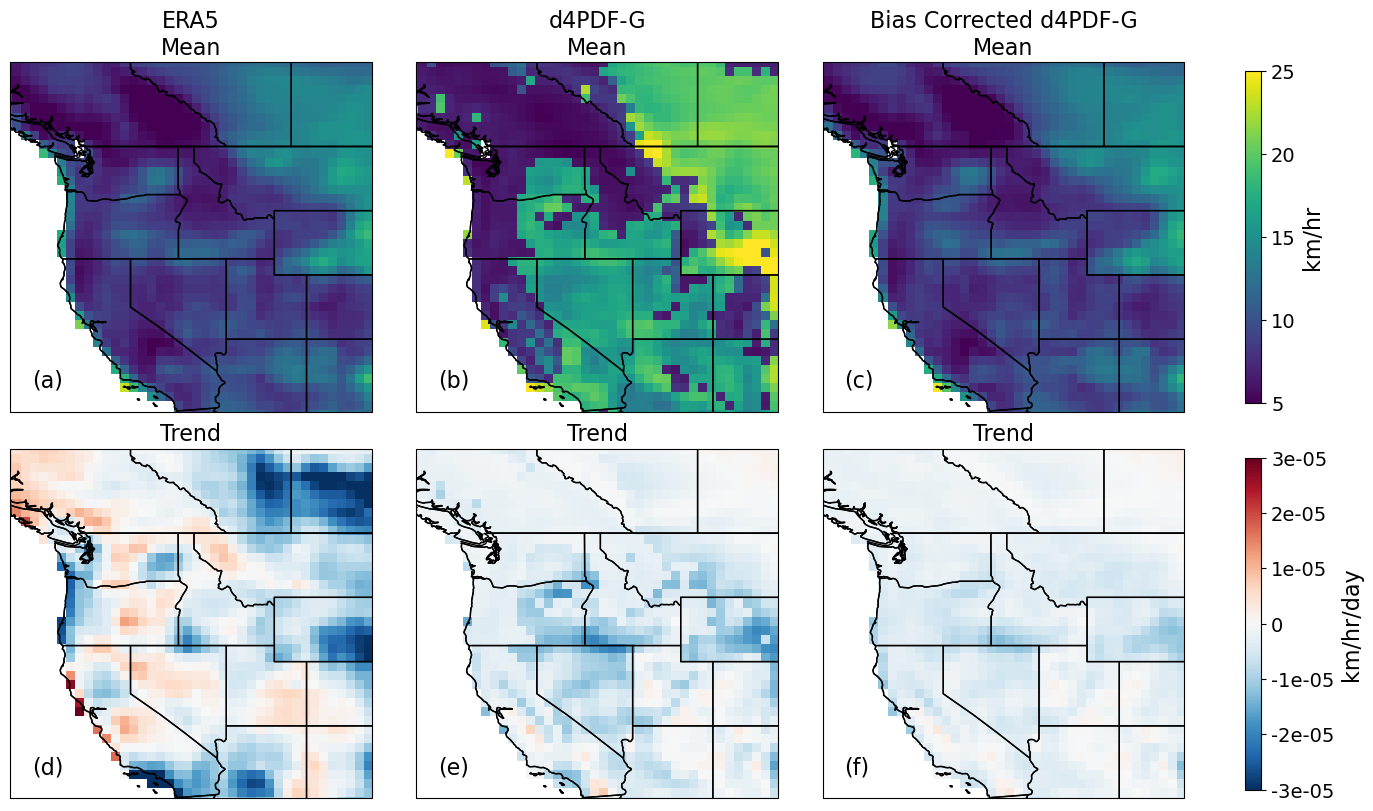

In [83]:
font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 16,
        }

fig,axs = plt.subplots(2,3,figsize=(14,8),layout='constrained',subplot_kw=dict(projection=ccrs.PlateCarree()))
axs = axs.flatten()

mean_das = [era5_mean,model_mean,model_bc_mean]
trend_das = [era5_trend,model_trend,model_bc_trend]

titles = ['ERA5','d4PDF-G', 'Bias Corrected d4PDF-G']
labels = ['a','b','c','d','e','f','g','h']

for i in range(len(mean_das)):
    # mean
    mean_im = mean_das[i].plot(ax=axs[i],vmin=5,vmax=25,add_colorbar=False)
    axs[i].set_title(titles[i] + '\nMean',fontdict=font)
    axs[i].set_ylabel('')
    axs[i].set_xlabel('')
    
    # trend
    trend_im = trend_das[i].plot(ax=axs[i+3],vmin=-3e-5,vmax=3e-5,cmap='RdBu_r',add_colorbar=False)
    axs[i+3].set_title('Trend',fontdict=font)
    axs[i+3].set_ylabel('')
    axs[i+3].set_xlabel('')
    
for i,ax in enumerate(axs):
    ax.coastlines()
    ax.add_feature(cf.BORDERS)
    ax.add_feature(cf.STATES)
    ax.set_extent([232.5,255, 32.5,54.18])#, crs=noproj)
    ax.text(0.06,0.07,'('+labels[i]+')',transform=ax.transAxes,fontdict=font)

mean_cb = fig.colorbar(mean_im, ax=axs[:3], shrink=0.95, orientation='vertical')
font['size'] = 16
mean_cb.set_label(label='km/hr',fontdict=font)
font['size']=14
mean_cb.set_ticks([5,10,15,20,25],labels=[str(val) for val in [5,10,15,20,25]],fontdict=font)

trend_cb = fig.colorbar(trend_im, ax=axs[3:6], shrink=0.95, orientation='vertical')
font['size'] = 16
trend_cb.set_label(label='km/hr/day',fontdict=font)
font['size']=14
trend_cb.set_ticks([-0.00003,-0.00002,-0.00001,0,0.00001,0.00002,0.00003],labels=[str(val) for val in [-0.00003,-0.00002,-0.00001,0,0.00001,0.00002,0.00003]],fontdict=font)

plt.savefig('/home/queenle/fire_attribution/figures/SupMat_Figure3.png',dpi=300,transparent=False, bbox_inches='tight')#, pad_inches=0.35)


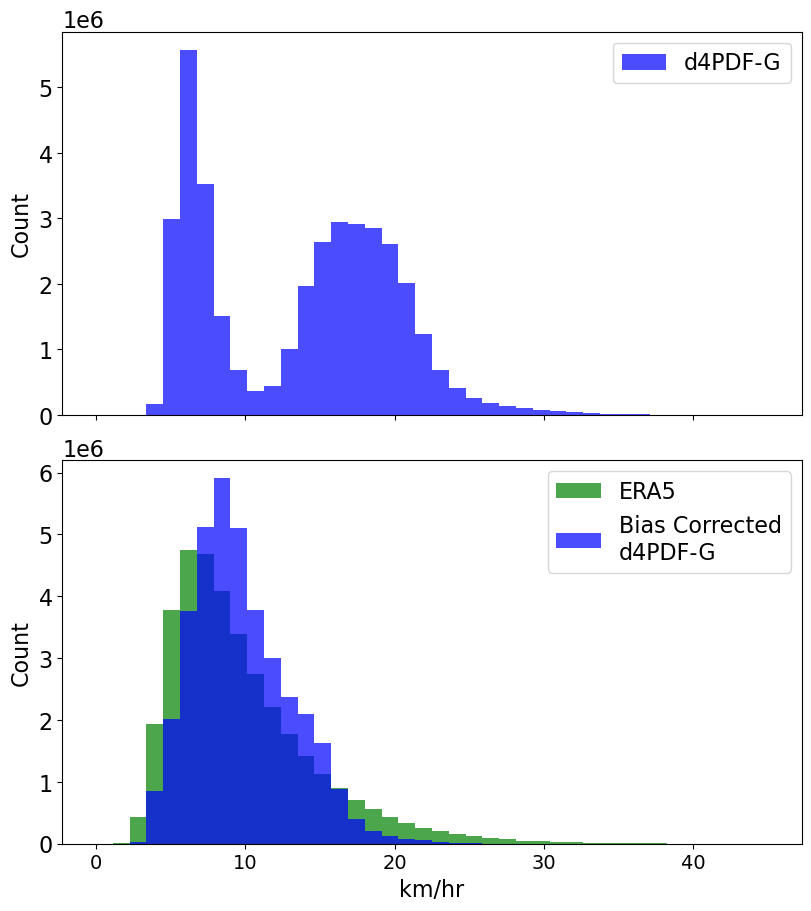

In [82]:
matplotlib.rcParams['font.size']=16

fig,axs = plt.subplots(2,1,figsize=(8,9),layout='constrained',sharex=True)
axs = axs.flatten()

axs[0].hist(model_da.data.flatten(),40,range=[0,45],color='blue',alpha=0.7,label='d4PDF-G')

axs[1].hist(era5_da.data.flatten(),40,range=[0,45],color='green',alpha=0.7,label='ERA5')
axs[1].hist(model_bc_wind.data.flatten(),40,range=[0,45],color='blue',alpha=0.7,label='Bias Corrected\nd4PDF-G')

axs[0].legend(fontsize=16)
axs[1].legend(fontsize=16)
axs[1].set_xticks([0,10,20,30,40])
axs[1].set_xticklabels([str(val) for val in [0,10,20,30,40]],fontdict=font)

axs[1].set_yticks([0, 1000000, 2000000, 3000000, 4000000, 5000000,6000000])
#axs[1].set_yticklabels([str(val) for val in [0, 1000000, 2000000, 3000000, 4000000, 5000000,6000000]],fontdict=font)
axs[1].ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
axs[1].set_xlabel('km/hr')
axs[0].set_ylabel('Count')
axs[1].set_ylabel('Count')

plt.savefig('/home/queenle/fire_attribution/figures/SupMat_Figure4.png',dpi=300,transparent=False, bbox_inches='tight')#, pad_inches=0.35)


In [68]:
axs[0].get_yticks()

array([      0., 1000000., 2000000., 3000000., 4000000., 5000000.,
       6000000.])

/home/queenle/.local/lib/python3.6/site-packages/numpy/lib/histograms.py:839: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/home/queenle/.local/lib/python3.6/site-packages/numpy/lib/histograms.py:840: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


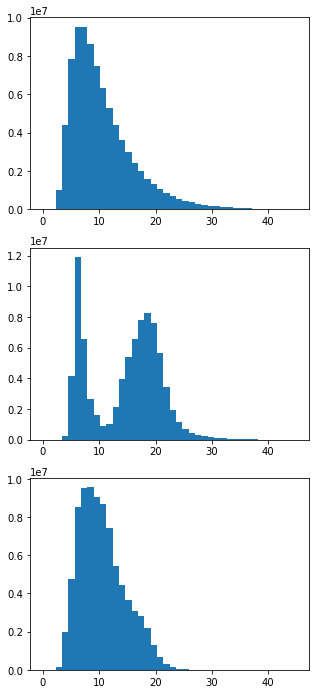

In [107]:
fig,axs = plt.subplots(3,1,figsize=(5,12))
axs = axs.flatten()

axs[0].hist(era5_da.data.flatten(),40,range=[0,45])
axs[1].hist(model_da.data.flatten(),40,range=[0,45])
axs[2].hist(model_bc_wind.data.flatten(),40,range=[0,45])

plt.show()

In [103]:
model_bc_wind.max()

<xarray.DataArray 'wind' ()>
array(34.83129469)

/home/queenle/.local/lib/python3.6/site-packages/numpy/lib/histograms.py:839: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/home/queenle/.local/lib/python3.6/site-packages/numpy/lib/histograms.py:840: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)
/home/queenle/.local/lib/python3.6/site-packages/numpy/lib/histograms.py:839: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/home/queenle/.local/lib/python3.6/site-packages/numpy/lib/histograms.py:840: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


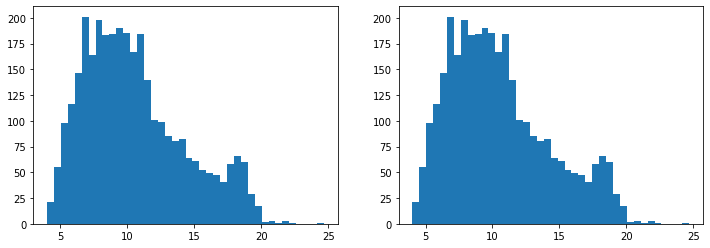

In [98]:
fig,axs = plt.subplots(1,2,figsize=(12,4))
axs = axs.flatten()

axs[0].hist(model_bc_wind.mean('time').data.flatten(),40)
axs[1].hist(era5_da.mean('time').data.flatten(),40)

plt.show()

In [ ]:
plt.hist(model_bc_wind.data.flatten(),40)
